# Analyzing Business License Distribution Across NYC Boroughs

For Project 2, I originally wanted to compare 311 complaints with climate data, but the years in the two datasets did not match, so it was impossible to merge them. I still visualized both datasets on one chart to show their trends, and this taught me an important lesson about knowing when a comparison cannot be made. For Project 3, I first considered studying a specific 311 complaint type such as HEAT/HOT WATER, but the dataset was too small to analyze. Instead, I decided to explore business activity in New York City by analyzing which boroughs issue the most business licenses and what this reveals about the city’s economic landscape. 

## Research question:
*Which New York City borough issues the most business licenses, and what types of businesses are licensed across the city?*

*My hypothesis is that Manhattan will have the highest number of issued licenses, reflecting its role as the commercial and economic center of NYC. However, I also expect meaningful patterns in Brooklyn and Queens due to their rapidly growing small-business ecosystems.*

## About the Data: 
The dataset I am using is the Issued Licenses dataset from NYC Open Data, which contains records of business licenses issued across New York City. Each row represents a single license and includes details such as the license category, license type, the borough where it was issued, and the date it was created. The dataset spans many different business activities and provides enough geographic and categorical detail to compare licensing patterns across boroughs.

For this project, I will focus on the following columns:
- Borough
- LicenseCategory
- LicenseType
- LicenseCreationDate

Dataset link: https://data.cityofnewyork.us/Business/Issued-Licenses/w7w3-xahh/about_data



In [2]:
import pandas as pd

df = pd.read_csv('Issued_Licenses.csv')
df.head()


/var/folders/ks/6q555h1j1ql6g_qy15k3_cb40000gn/T/ipykernel_8990/3899788973.py:3: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Issued_Licenses.csv')


,License Number,Business Name,DBA/Trade Name,Business Unique ID,Business Category,License Type,License Status,Initial Issuance Date,Expiration Date,Details,...,Borough,Community Board,Council District,BIN,BBL,NTA,Census Block (2010),Census Tract (2010),Latitude,Longitude
0,2123226-DCWP,Denis Spedalieri,NaN,BA-1703334-2024,Sightseeing Guide,Individual,Active,08/01/2024,03/31/2026,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2108901-DCA,SMC PROFESSIONAL CONSTRUCTION INC,NaN,BA-1557348-2022,Home Improvement Contractor,Premises,Active,09/19/2022,02/28/2027,NaN,...,Outside NYC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2104594-DCA,Jcads Inc,NaN,BA-1326457-2022,Home Improvement Contractor,Premises,Active,03/21/2022,02/28/2027,NaN,...,Bronx,212.0,12.0,2069456.0,2.050280e+09,BX62,1005.0,448.0,40.89405,-73.838531
3,2122058-DCWP,CTRL VINTAGE LLC,NaN,BA-1698529-2024,Secondhand Dealer - General,Premises,Active,06/07/2024,07/31/2027,NaN,...,Brooklyn,303.0,36.0,3043437.0,3.016070e+09,BK35,2000.0,289.0,40.69200,-73.933844
4,2071051-DCA,MAESTRO BUILDERS CORPORATION,NaN,BA-1451017-2022,Home Improvement Contractor,Premises,Active,05/11/2018,02/28/2027,NaN,...,Queens,402.0,26.0,4053029.0,4.022890e+09,QN31,3000.0,18501.0,40.73901,-73.919540


## Licenses by borough

To answer the first part of my research question, I counted how many business licenses were issued in each borough. The interactive bar chart below shows the total number of licenses by borough, along with values on each bar for easy comparison.


In [3]:
cols = [
    "Borough",
    "Business Category",
    "License Type",
    "License Status",
    "Initial Issuance Date"
]

df_clean = df[cols].copy()

# Drop rows with missing boroughs
df_clean = df_clean.dropna(subset=["Borough"])

# Standardize borough names
df_clean["Borough"] = df_clean["Borough"].str.title()

# Convert issuance date to datetime
df_clean["Initial Issuance Date"] = pd.to_datetime(
    df_clean["Initial Issuance Date"],
    errors="coerce"
)

# Drop rows with invalid dates
df_clean = df_clean.dropna(subset=["Initial Issuance Date"])

df_clean.head()


,Borough,Business Category,License Type,License Status,Initial Issuance Date
1,Outside Nyc,Home Improvement Contractor,Premises,Active,2022-09-19
2,Bronx,Home Improvement Contractor,Premises,Active,2022-03-21
3,Brooklyn,Secondhand Dealer - General,Premises,Active,2024-06-07
4,Queens,Home Improvement Contractor,Premises,Active,2018-05-11
5,Queens,Secondhand Dealer - General,Premises,Expired,2019-08-07


In [4]:
borough_counts = (
    df_clean.groupby("Borough")
    .size()
    .sort_values(ascending=False)
)

borough_counts


Borough
Queens           12799
Brooklyn         12658
Manhattan         9742
Bronx             5989
Outside Nyc       3731
Staten Island     2924
dtype: int64

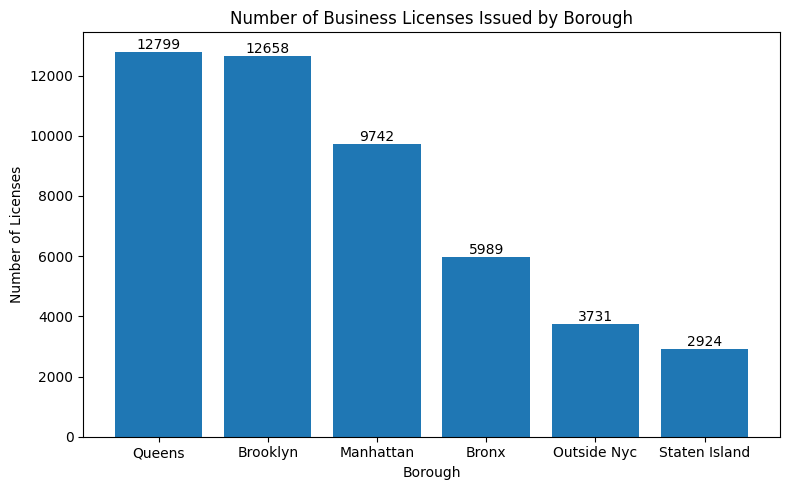

In [5]:
import matplotlib.pyplot as plt

# Reset index if Borough is the index
data = borough_counts.reset_index()
data.columns = ["Borough", "Number of Licenses"]

plt.figure(figsize=(8, 5))
plt.bar(data["Borough"], data["Number of Licenses"])

# Labels and title
plt.title("Number of Business Licenses Issued by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Licenses")

# Add value labels on top of bars
for i, value in enumerate(data["Number of Licenses"]):
    plt.text(i, value, f"{value}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


Queens has the highest number of licenses, followed by Brooklyn and Manhattan. The Bronx, Outside NYC and Staten Island have fewer licenses overall, which suggests that formal business activity is more concentrated in Queens and Brooklyn.

## Business Categories

Next, I examined which types of businesses are most common in NYC. I calculated the top 10 most frequent business categories in the dataset and plotted them as a horizontal bar chart for readability.


In [6]:
category_counts = df_clean["Business Category"].value_counts().head(10)
category_counts.reset_index()

,Business Category,count
0,Home Improvement Contractor,15929
1,Tobacco Retail Dealer,6435
2,Secondhand Dealer - General,5186
3,Electronics Store,4012
4,Electronic Cigarette Dealer,2689
5,Garage & Parking Lot,2605
6,Stoop Line Stand,2547
7,Dealer In Products For The Disabled,1805
8,Electronic & Home Appliance Service Dealer,1734
9,Hotel,766


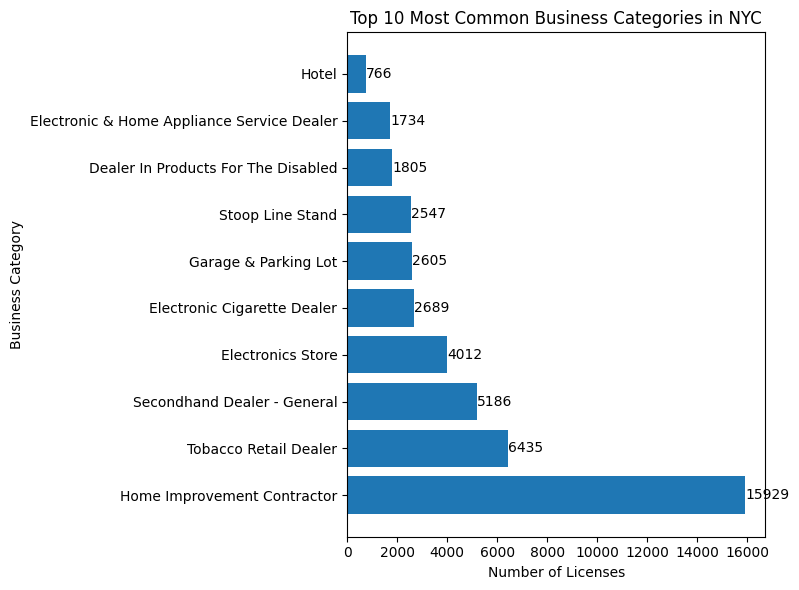

In [16]:
import matplotlib.pyplot as plt

# Prepare data
df_cat = category_counts.reset_index()
df_cat.columns = ["Category", "Count"]

plt.figure(figsize=(8, 6))
plt.barh(df_cat["Category"], df_cat["Count"])

# Title and labels
plt.title("Top 10 Most Common Business Categories in NYC")
plt.xlabel("Number of Licenses")
plt.ylabel("Business Category")

# Add value labels at the end of each bar
for i, value in enumerate(df_cat["Count"]):
    plt.text(value, i, f"{value}", va="center")

plt.tight_layout()
plt.show()


A small number of categories account for a large share of licenses. For example, Home Improvement Contractor, Tobacco Retail Dealer, and Second Hand Dealer appear most frequently. This suggests that certain sectors dominate NYC’s licensed business landscape.

## Business Categories by Borough

To understand how business types vary across boroughs, I focused on the top five business categories citywide and counted how many licenses each borough issued in those categories. The grouped bar chart below shows the distribution of these categories across boroughs.


In [9]:
import plotly.express as px

# Top 5 categories citywide
top_categories = df_clean["Business Category"].value_counts().head(5).index

df_top = df_clean[df_clean["Business Category"].isin(top_categories)]

category_by_borough_long = (
    df_top
    .groupby(["Borough", "Business Category"])
    .size()
    .reset_index(name="Count")
)

category_by_borough_long.head()


,Borough,Business Category,Count
0,Bronx,Electronic Cigarette Dealer,266
1,Bronx,Electronics Store,841
2,Bronx,Home Improvement Contractor,1282
3,Bronx,Secondhand Dealer - General,869
4,Bronx,Tobacco Retail Dealer,1101


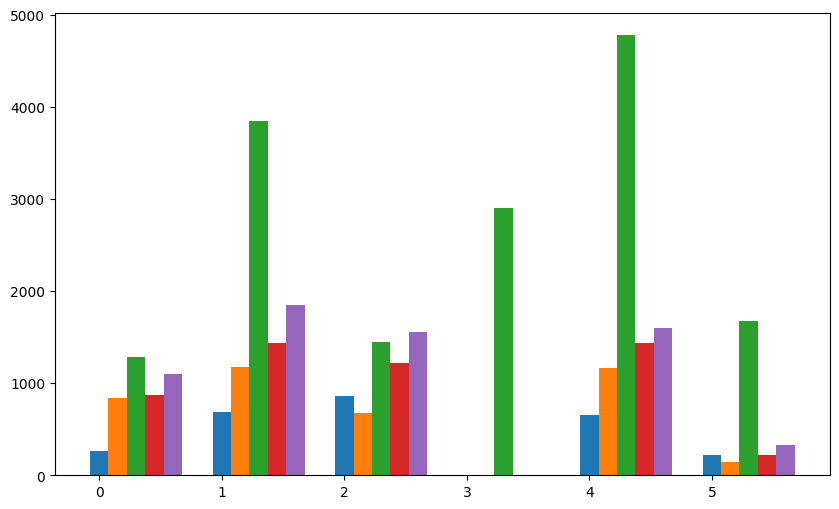

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = category_by_borough_long.copy()

boroughs = df["Borough"].unique()
categories = df["Business Category"].unique()

x = np.arange(len(boroughs))
bar_width = 0.15  # adjust if needed

plt.figure(figsize=(10, 6))

# Draw grouped bars
for i, category in enumerate(categories):
    values = (
        df[df["Business Category"] == category]
        .set_index("Borough")
        .reindex(boroughs)["Count"]
    )
    plt.bar(x + i * bar_width, values, width=bar_width, label=category)

# Title


Home Improvement Contractor is the most prominent business category in NYC, ranking first in every borough. The second most common category is Tobacco Retail Dealer, which also consistently appears in second place across all boroughs. We can also see that Queens, Manhattan, Brooklyn, and the Bronx share a similar distribution of business types, whereas Staten Island shows a noticeably different pattern.

## Choropleth Map of Licenses by Borough

Finally, I created a choropleth map to visualize the geographic pattern of business licensing. Each borough is shaded according to the number of licenses it has, with darker colors representing more licenses.


In [12]:
borough_counts_df = borough_counts.reset_index()
borough_counts_df.columns = ["Borough", "Count"]

# Clean and standardize names to match GeoJSON 'boroname' values
borough_counts_df["Borough"] = (
    borough_counts_df["Borough"]
    .astype(str)
    .str.strip()
    .str.title()
)

print("Boroughs in borough_counts_df:", sorted(borough_counts_df["Borough"].unique()))


Boroughs in borough_counts_df: ['Bronx', 'Brooklyn', 'Manhattan', 'Outside Nyc', 'Queens', 'Staten Island']


In [13]:
import json

with open("boroughs.geojson") as f:
    geojson = json.load(f)


In [21]:
pip install geopandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 54.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 58.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 47.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]/4 [geopandas]
Note: you may need to restart the kernel to use updated packages.


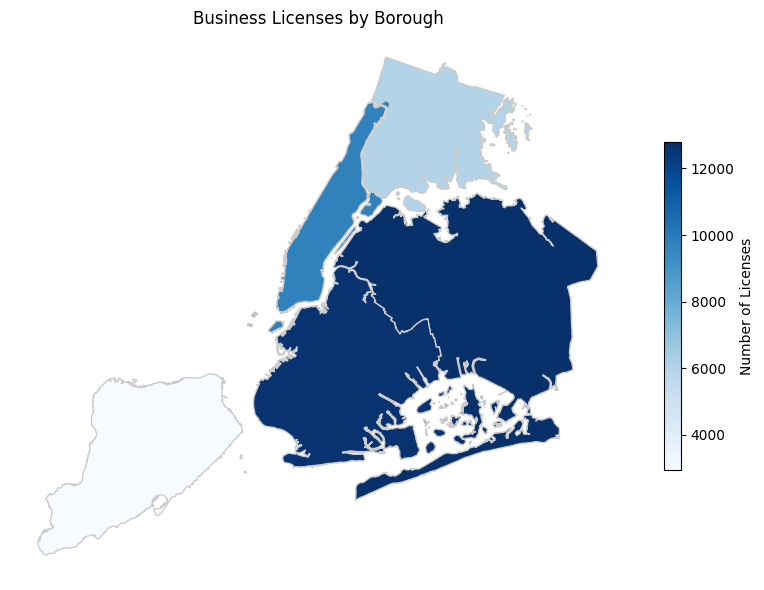

In [22]:
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import pandas as pd
import numpy as np

# Prepare lookup from borough -> count
count_dict = dict(zip(borough_counts_df["Borough"], borough_counts_df["Count"]))

fig, ax = plt.subplots(figsize=(8, 6))

patches = []
values = []

for feature in geojson["features"]:
    borough = feature["properties"]["boroname"]
    count = count_dict.get(borough, 0)

    coords = feature["geometry"]["coordinates"]

    if feature["geometry"]["type"] == "Polygon":
        for poly in coords:
            patches.append(Polygon(poly))
            values.append(count)

    elif feature["geometry"]["type"] == "MultiPolygon":
        for multipoly in coords:
            for poly in multipoly:
                patches.append(Polygon(poly))
                values.append(count)

collection = PatchCollection(
    patches,
    cmap="Blues",
    edgecolor="0.8"
)
collection.set_array(np.array(values))

ax.add_collection(collection)
ax.autoscale_view()
ax.axis("off")

plt.title("Business Licenses by Borough")
plt.colorbar(collection, shrink=0.6, label="Number of Licenses")

plt.tight_layout()
plt.show()


The map reinforces the pattern shown in the bar chart: Queens, Brooklyn, and the Bronx appear as high-density clusters of licensed businesses, while Staten Island shows the lowest concentration. This visualization makes it easier to understand how business activity varies across the city’s geography.

# Findings

Across the city, business licensing is unevenly distributed, with Queens emerging as the primary hub of licensed activity, followed by Brooklyn and Manhattan. This pattern reflects a blend of population size, commercial density, and the concentration of small businesses in outer-borough neighborhoods. Staten Island and the Bronx show substantially fewer licenses, indicating that formal business activity is less concentrated there.

Citywide, the licensed business landscape is dominated by only a few categories. Home Improvement Contractors represent by far the largest share and maintain this lead in every borough, suggesting that household services and renovations play a major role in NYC’s regulated economy. Tobacco Retail Dealers consistently appear as the second most common category, reflecting long-standing regulatory requirements for selling tobacco products. Although the major categories are similar across boroughs, Staten Island stands out with a noticeably different distribution, suggesting a more specialized or less diverse set of licensed activities compared with the other boroughs.

When viewed spatially, the choropleth map brings these trends into clearer focus. Queens and Brooklyn form the strongest clusters of licensed businesses, with the Bronx showing moderate density and Staten Island showing the lowest. The map reinforces the idea that business licensing and by extension, formal economic activity is concentrated in certain parts of the city, particularly in areas with large residential and commercial populations.

# Conclusion

This project examined the question: *Which New York City borough issues the most business licenses, and what types of businesses are licensed across the city?* I originally hypothesized that **Manhattan** would lead in total licenses issued, given its historic role as the city’s commercial and economic core. I also expected Brooklyn and Queens to show significant activity due to their expanding small-business environments.

The results, however, challenge the initial assumption. **Queens**, not Manhattan, issued the highest number of business licenses, with Brooklyn following and Manhattan ranking third. This finding suggests that formal business activity is increasingly dispersed across the outer boroughs, likely influenced by population distribution, neighborhood-level commerce, and the growth of home-based and small-scale enterprises. In contrast, Staten Island and the Bronx showed substantially fewer licenses, indicating smaller or more localized business ecosystems.

The analysis of business types revealed that NYC’s licensed landscape is dominated by a small number of categories. **Home Improvement Contractors and Tobacco Retail Dealers** consistently appear as the top two categories across nearly every borough. While most boroughs share a similar distribution of business types, Staten Island presents a noticeably different pattern, suggesting a more specialized or less diverse set of licensed activities.

Overall, the findings show that business licensing in NYC is both geographically uneven and economically concentrated in specific sectors. The evidence highlights the growing importance of Queens and Brooklyn as centers of licensed commercial activity, which contrasts with the initial hypothesis. Future extensions of this project could explore licensing trends over time, neighborhood-level differences within boroughs, or relationships between business licensing and demographic or economic indicators.